이번 주차 과제는 간단한 이미지 데이터를 활용해 크기가 큰 데이터의 차원 축소를 진행하고 데이터의 라벨에 따라 클러스터링을 진행하는 과제입니다.

###필요한 모듈을 가져오세요.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error


# Image data 가져오기
https://www.kaggle.com/datasets/zalando-research/fashionmnist/data

###위 링크의 fashion mnist 데이터의 train dataset과 test dataset을 가져오세요.
(데이터의 용량이 크니 직접 다운로드 하지 말고 코드를 이용해 가져오도록 해보세요.)

In [3]:
# Fashion MNINST 데이터셋 불러오기
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print(f"Train images shape: {train_images.shape}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


###데이터에 대한 정보들을 보여주세요.
(필수: 요약, 모양, 크기, 결측치 여부 등)

In [4]:
# 결측치 여부
missing_values = np.isnan(train_images).sum()
print(f"결측치가 존재하는 이미지: {missing_values}")

# 이미지 크기
image_shape = train_images.shape[1:]
print(f"이미지 크기: {image_shape}")

# label 별 이미지 개수
unique_labels, counts = np.unique(train_labels, return_counts=True)
summary = dict(zip(unique_labels, counts))
print(f"라벨별 이미지 개수 요약: {summary}")

결측치가 존재하는 이미지: 0
이미지 크기: (28, 28)
라벨별 이미지 개수 요약: {0: 6000, 1: 6000, 2: 6000, 3: 6000, 4: 6000, 5: 6000, 6: 6000, 7: 6000, 8: 6000, 9: 6000}


### Data중 첫 번째 이미지를 보여주세요.

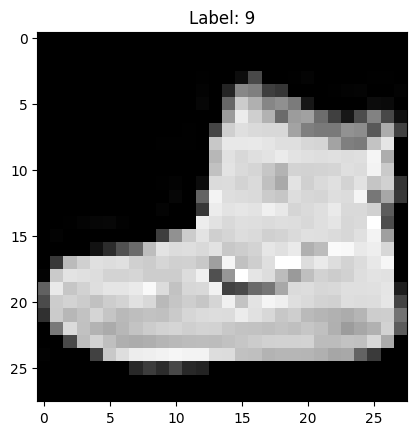

In [5]:
plt.imshow(train_images[0], cmap='gray')
plt.title(f"Label: {train_labels[0]}")
plt.show()
# train_images[0]

# 이미지 전처리

### 이미지 데이터를 머신러닝에 이용하기 편한 형태로 바꾸어 합니다.
(torch model 사용 - tensor 형태로 바꾸기 등)

In [6]:
# 이미지 데이터를 4차원 텐서로 변환
train_x = train_images.reshape(-1, 28, 28, 1).astype('float32')
test_x = test_images.reshape(-1, 28, 28, 1).astype('float32')

print(f"Train images shape after reshaping: {train_x.shape}")
print(f"Test images shape after reshaping: {test_x.shape}")

Train images shape after reshaping: (60000, 28, 28, 1)
Test images shape after reshaping: (10000, 28, 28, 1)


### 이미지 데이터는 픽셀 값이 0 - 255로 이루어져 있습니다. 이 값을 0 - 1까지의 값으로 normalize 해주세요.

In [7]:
# 모든 데이터가 0~1사이 값 갖도록 함
train_x = train_images/255.0
test_x = test_images/255.0
train_x[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

### 추가적인 이미지 전처리를 진행해주세요.
(차원을 수정하는 것은 뒤의 문제에서 진행할 것이므로 여기에서 하지 마세요.)

In [8]:
train_x.shape


(60000, 28, 28)

# 차원 축소
차원 축소란 고차원 데이터를 효율적으로 처리하기 위한 기법입니다.
### 그 중 대표적인 PCA와 t-sne에 대한 내용을 비교하여 아래에 적어주세요.

(더블클릭하여 이곳에 작성)

## PCA

### 현재 데이터는 28*28로 784차원을 가지고 있습니다. PCA를 이용하여 데이터들을 가장 잘 설명하는 50개의 변수만으로 데이터를 변환하시오.

In [9]:
# PCA 객체 생성 (50개의 주성분)
pca = PCA(n_components=50)

# train_x 데이터를 PCA로 변환
train_x_pca = pca.fit_transform(train_x.reshape(-1, 28*28))

print(f"Train data shape after PCA: {train_x_pca.shape}")

Train data shape after PCA: (60000, 50)


In [14]:
# 784차원 데이터를 50차원으로 축소한 데이터
train_x_pca[0]

array([-4.86250160e-01,  6.40421332e+00, -4.74918114e+00,  9.44286739e-01,
       -1.31307876e-02, -1.58564884e+00, -3.58845158e-01,  7.89706896e-01,
       -1.29081479e-01, -1.16899501e-01,  5.81472883e-01, -2.60731948e-01,
        1.94067796e-01, -5.38258258e-01,  4.35429302e-01, -1.79980554e-01,
        4.56781291e-01, -7.61633207e-01,  1.67177254e+00, -8.17846858e-01,
       -5.66957048e-01,  6.59456944e-01,  3.93495686e-01, -1.51179032e-01,
        8.54255674e-01,  1.64129513e-01, -4.31367686e-01, -4.53225182e-01,
       -4.43087125e-01,  3.81246421e-01, -3.61065657e-01, -1.22754638e+00,
       -2.36722630e-01, -1.08868117e-01, -1.61867870e-01, -2.78126516e-01,
        1.64607908e-01, -5.66995354e-01,  4.16339157e-02, -4.97157614e-01,
        2.64179096e-01, -3.48431398e-01,  2.95327143e-01, -4.40386647e-01,
       -2.56351195e-01, -6.90117943e-01,  5.50350769e-01, -6.63331439e-02,
       -2.86232480e-01, -4.92285301e-03])

In [16]:
pca.explained_variance_

array([19.80980567, 12.11221047,  4.10615661,  3.38182839,  2.62477022,
        2.36084678,  1.59744034,  1.2998236 ,  0.92082807,  0.89655881,
        0.6773136 ,  0.62299873,  0.52240376,  0.45003398,  0.41465993,
        0.40236086,  0.37651521,  0.35780014,  0.31248952,  0.31074029,
        0.29584764,  0.27771129,  0.26247189,  0.25414485,  0.24633757,
        0.23920852,  0.22732843,  0.21785889,  0.21015227,  0.20006295,
        0.18800804,  0.18081711,  0.17989115,  0.17452335,  0.16795891,
        0.16091421,  0.15709499,  0.15384437,  0.14903231,  0.14275958,
        0.13657601,  0.13349918,  0.13275865,  0.12461077,  0.11958298,
        0.11717208,  0.11484096,  0.11141184,  0.1089429 ,  0.10494293])

### PCA 이후 데이터들의 설명된 분산 비율 (explained variance ratio)를 출력하세요.

In [17]:
# 설명된 분산 비율 출력
explained_variance_ratio = pca.explained_variance_ratio_
print(f"Explained variance ratio: {explained_variance_ratio}")

Explained variance ratio: [0.29039228 0.1775531  0.06019222 0.04957428 0.03847655 0.03460769
 0.02341691 0.01905414 0.01349843 0.01314267 0.00992875 0.00913255
 0.00765793 0.00659706 0.00607851 0.00589821 0.00551934 0.005245
 0.00458079 0.00455515 0.00433684 0.00407097 0.00384758 0.00372551
 0.00361107 0.00350656 0.00333241 0.0031936  0.00308063 0.00293273
 0.00275601 0.0026506  0.00263703 0.00255834 0.00246211 0.00235884
 0.00230286 0.00225521 0.00218467 0.00209272 0.00200207 0.00195697
 0.00194611 0.00182667 0.00175297 0.00171763 0.00168346 0.00163319
 0.001597   0.00153836]


### PCA를 시행하면 데이터가 수정되므로 원본 데이터와 차이가 생기게 됩니다. 이때 이 차이를 재구성 오차(Reconstruction Error)라고 합니다. 재구성 오차를 mse(오차제곱합) 방식으로 구하시오.

In [22]:
# PCA로 축소된 데이터를 원본 공간으로 역변환
train_x_reconstructed = pca.inverse_transform(train_x_pca)

print(train_x_reconstructed.shape)

# 원본 데이터와 재구성된 데이터 간의 MSE 계산
reconstruction_error = mean_squared_error(train_x.reshape(-1, 28*28), train_x_reconstructed)
print(f"Reconstruction Error (MSE): {reconstruction_error}")

(60000, 784)
Reconstruction Error (MSE): 0.0119507017536183


### 이번에는 PCA를 통해 원본 데이터를 30차원으로 줄이고, explained variance ratio와 reconstructon error를 구하시오.

In [26]:
# PCA 객체 생성 (30개의 주성분)
pca_30 = PCA(n_components=30)

# train_x 데이터를 PCA로 변환
train_x_pca_30 = pca_30.fit_transform(train_x.reshape(-1, 28*28))

# 설명된 분산 비율 출력
explained_variance_ratio_30 = pca_30.explained_variance_ratio_
print(f"설명된 된 분산: {explained_variance_ratio_30}")

# PCA로 축소된 데이터를 원본 공간으로 역변환
train_x_reconstructed_30 = pca_30.inverse_transform(train_x_pca_30)

# 원본 데이터와 재구성된 데이터 간의 MSE 계산
reconstruction_error_30 = mean_squared_error(train_x.reshape(-1, 28*28), train_x_reconstructed_30)
print(f"Reconstruction Error (MSE): {reconstruction_error_30}")

설명된 된 분산: [0.29039228 0.1775531  0.06019222 0.04957428 0.03847655 0.03460769
 0.02341691 0.01905414 0.01349843 0.01314267 0.00992875 0.00913255
 0.00765793 0.00659706 0.00607851 0.00589821 0.00551934 0.005245
 0.00458077 0.00455513 0.00433682 0.0040709  0.00384751 0.00372544
 0.00361089 0.00350621 0.00333161 0.00319267 0.00307961 0.00292939]
Reconstruction Error (MSE): 0.015598156139996242


### 데이터를 30차원으로 줄인 결과와 50차원으로 줄인 결과에는 어떤 차이가 있습니까?

차이는 거의 없으나 30차원으로 줄였을 때 MSE가 50차원으로 줄였을 때에 비해 높은 것을 알 수 있다.

### 마지막으로 원본 데이터를 2차원으로 줄이고, explained variance ratio와 reconstruction error를 구하시오.

In [28]:
# PCA 객체 생성
pca_2 = PCA(n_components=2)

# train_x 데이터를 PCA로 변환
train_x_pca_2 = pca_2.fit_transform(train_x.reshape(-1, 28*28))

# 설명된 분산 비율 출력
explained_variance_ratio_2 = pca_2.explained_variance_ratio_
print(f"설명된 된 분산: {explained_variance_ratio_2}")

# PCA로 축소된 데이터를 원본 공간으로 역변환
train_x_reconstructed_2 = pca_2.inverse_transform(train_x_pca_2)

# 원본 데이터와 재구성된 데이터 간의 MSE 계산
reconstruction_error_2 = mean_squared_error(train_x.reshape(-1, 28*28), train_x_reconstructed_2)
print(f"Reconstruction Error (MSE): {reconstruction_error_2}")

설명된 된 분산: [0.29039228 0.1775531 ]
Reconstruction Error (MSE): 0.04629435827776491


### 2차원으로 축소한 데이터를 시각화하여 보여주세요. 대신 데이터의 label에 따라 색상을 다르게 해주세요.

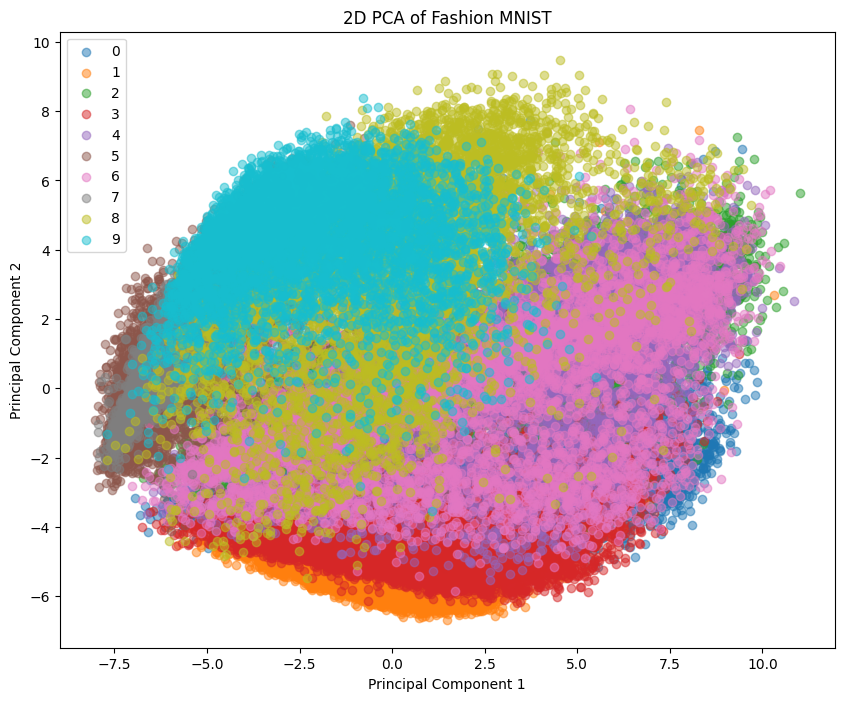

In [30]:
plt.figure(figsize=(10, 8))
for label in unique_labels:
  plt.scatter(train_x_pca_2[train_labels == label, 0], train_x_pca_2[train_labels == label, 1], label=label, alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA of Fashion MNIST')
plt.legend()
plt.show()

## T-SNE

### 앞서 pca를 통해 50차원으로 줄인 데이터를 t-sne를 통해 시각화 하세요.

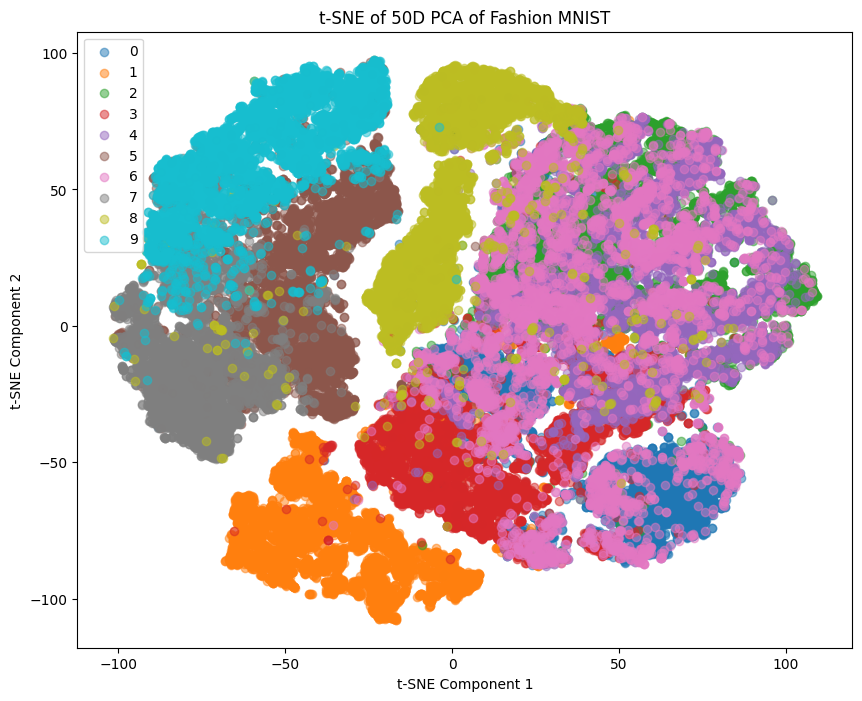

In [31]:
from sklearn.manifold import TSNE

# t-SNE 객체 생성
tsne = TSNE(n_components=2, random_state=42)

# 50차원 데이터를 2차원으로 변환
train_x_tsne = tsne.fit_transform(train_x_pca)

# 시각화
plt.figure(figsize=(10, 8))
for label in unique_labels:
  plt.scatter(train_x_tsne[train_labels == label, 0], train_x_tsne[train_labels == label, 1], label=label, alpha=0.5)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE of 50D PCA of Fashion MNIST')
plt.legend()
plt.show()

### 앞서 pca를 통해 30차원으로 줄인 데이터를 t-sne를 통해 시각화 하세요.

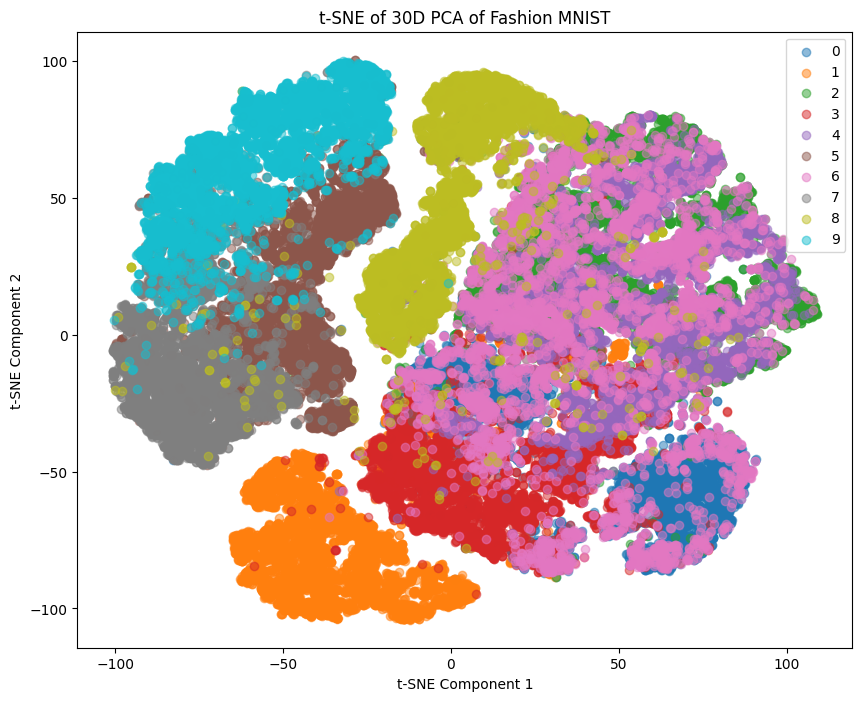

In [32]:
# t-SNE 객체 생성
tsne = TSNE(n_components=2, random_state=42)

# 30차원 데이터를 2차원으로 변환
train_x_tsne_30 = tsne.fit_transform(train_x_pca_30)

plt.figure(figsize=(10, 8))
for label in unique_labels:
  plt.scatter(train_x_tsne_30[train_labels == label, 0], train_x_tsne_30[train_labels == label, 1], label=label, alpha=0.5)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE of 30D PCA of Fashion MNIST')
plt.legend()
plt.show()

## 군집화

### PCA를 통해 50차원으로 줄인 데이터를 DBSCAN을 이용하여 군집화 하시오.

In [ ]:
# DBSCAN 객체 생성
dbscan = DBSCAN(eps=3, min_samples=5)# DBSCAN 객체 생성

### k-means를 통해 50차원으로 줄인 데이터를 군집화 하시오.(군집의 개수는 10개로 하시오.)

### 엘보우 메소드를 이용하여 k-means에서 가장 적절한 군집의 개수를 구하시오.

### k-means 최적의 군집 개수로 다시 군집화 하여 시각화 하시오.

### 다른 추가적인 군집화 기법을 2가지 이상 사용하여 pca 50 데이터를 시각화 하시오.

## 군집화 결과 비교

### 앞선 모든 군집화 모델의 결과를 실루엣 점수(Silhouette score)를 이용하여 성능을 비교하시오.

### 실루엣 점수를 통해 군집화 모델의 성능에 대한 간단한 해석을 적으세요.


(더블클릭해서 이곳에 작성)